Histogram charting of frequencies for stop times at locations used by average_stop_time.py

2026-04-03 11:03:41 - ml.cache - INFO - Loading stops data from /home/cyrus/shubble/ml/cache/shared/stops_data_max_distance0p005_max_timedelta30_min_segment_length3_window_size5.csv


2026-04-03 11:03:41,538 - ml.cache - INFO - Loading stops data from /home/cyrus/shubble/ml/cache/shared/stops_data_max_distance0p005_max_timedelta30_min_segment_length3_window_size5.csv


2026-04-03 11:03:42 - ml.cache - INFO - Loaded 410347 records from cache


2026-04-03 11:03:42,386 - ml.cache - INFO - Loaded 410347 records from cache
2026-04-03 11:03:42,513 - average_stop_time - INFO - Calculated stop times for 35 unique stops


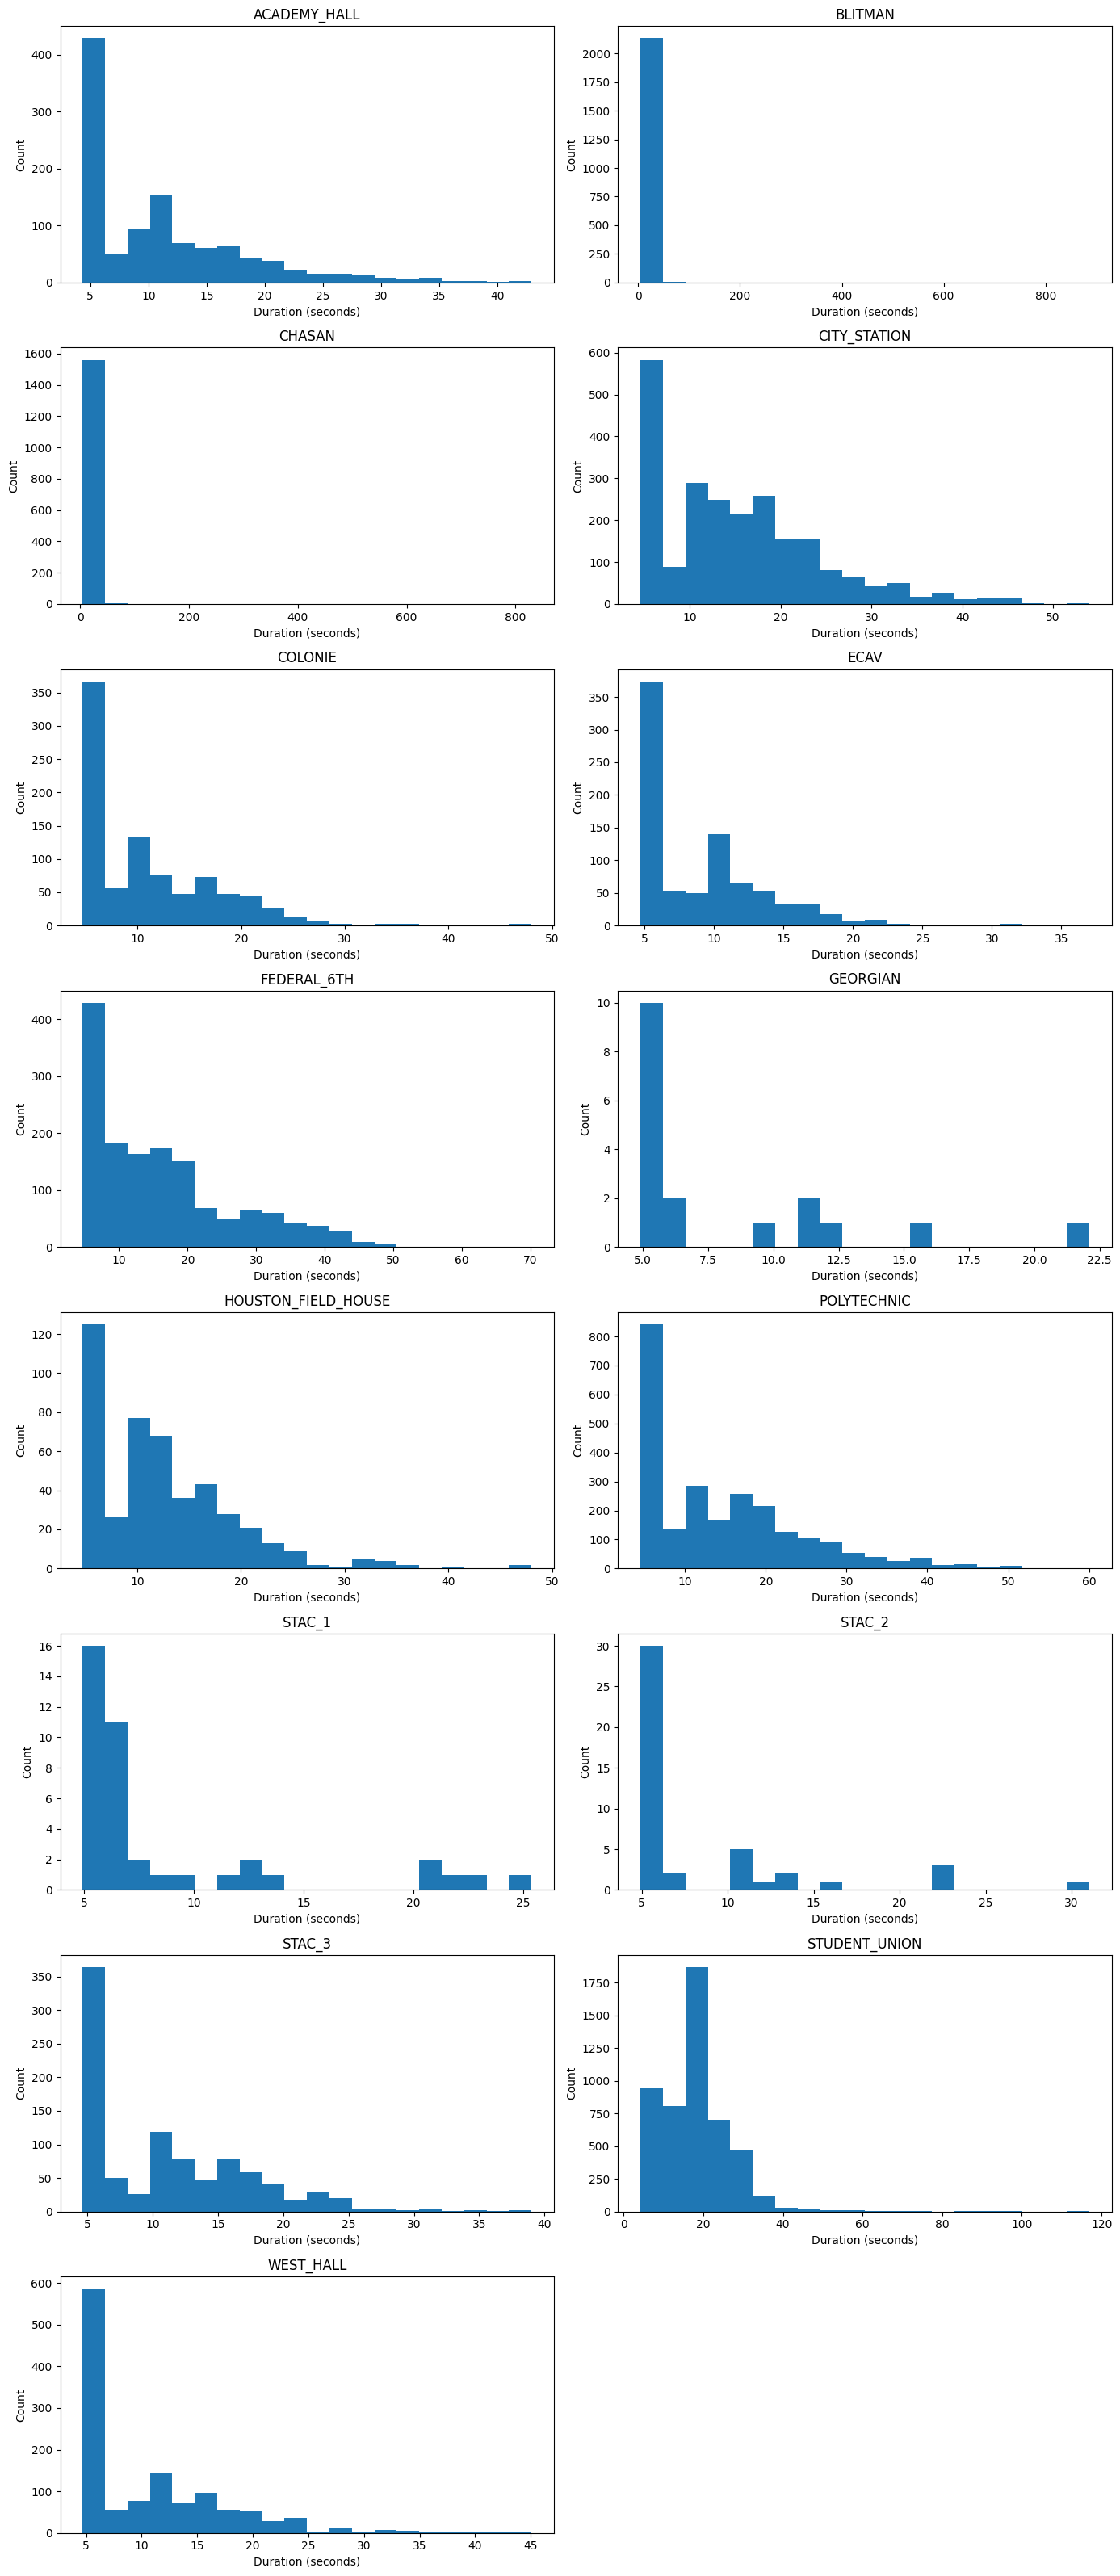

In [ ]:
#!/usr/bin/env python3

# ================================================================= #
# Use the histograms to verify the function of average_stop_time.py #
# ================================================================= #

import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ml.pipelines import stops_pipeline
from average_stop_time import calculate_stop_times

df = stops_pipeline()
stop_stats, visit_durations = calculate_stop_times(df)

stops = list(visit_durations['stop_name'].unique())
n_cols = 2
n_rows = -(-len(stops) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, (stop_name, group) in enumerate(visit_durations.groupby('stop_name')):
    axes[i].hist(group['duration'], bins=20)
    axes[i].set_title(stop_name)
    axes[i].set_xlabel('Duration (seconds)')
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()